In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import importlib

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import encoder_classifier as ec
importlib.reload(ec)

<module 'encoder_classifier' from 'c:\\Users\\Utente\\Desktop\\uni\\MAGISTRALE\\___TESI_magistrale\\github\\prove_modelli\\encoder_classifier.py'>

# 0. DATA LOADING

In [10]:
# -------------       
# DATASET PATHS
# -------------
train_path = r"C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TRAIN_set.csv"
test_path = r"C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TEST_set.csv"

# -------------------------
# TRAINING DATA PREPARATION
# -------------------------
train_dataset, train_loader, waves_train, labels_train = ec.dataload(train_path)


# ---------------------
# TEST DATA PREPARATION
# ---------------------
test_dataset, test_loader, waves_test, labels_test = ec.dataload(test_path)


# ---------------------------
# TEST PLOT TO VISUALISE DATA
# ---------------------------
# ec.plot_wave(waves_train)
# ec.plot_wave(waves_test)

This function loads the data from the specified path and returns (in this order): 
 - the dataset - the loader - the waves and labels
Loading data from C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TRAIN_set.csv...
Data loaded successfully. Waves shape: torch.Size([3601, 1, 500]), Labels shape: torch.Size([3601])
This function loads the data from the specified path and returns (in this order): 
 - the dataset - the loader - the waves and labels
Loading data from C:\Users\Utente\Desktop\uni\MAGISTRALE\___TESI_magistrale\github\prove_modelli\FordA\TEST_set.csv...
Data loaded successfully. Waves shape: torch.Size([1320, 1, 500]), Labels shape: torch.Size([1320])


# 1. AUTOENCODER training + test

Epoch [1/500] - Average loss: 0.4118
Epoch [2/500] - Average loss: 0.1207
Epoch [3/500] - Average loss: 0.0682
Epoch [4/500] - Average loss: 0.0528
Epoch [5/500] - Average loss: 0.0375
Epoch [6/500] - Average loss: 0.0304
Epoch [7/500] - Average loss: 0.0254
Epoch [8/500] - Average loss: 0.0210
Epoch [9/500] - Average loss: 0.0157
Epoch [10/500] - Average loss: 0.0142
Epoch [11/500] - Average loss: 0.0186
Epoch [12/500] - Average loss: 0.0119
Epoch [13/500] - Average loss: 0.0105
Epoch [14/500] - Average loss: 0.0101
Epoch [15/500] - Average loss: 0.0096
Epoch [16/500] - Average loss: 0.0096
Epoch [17/500] - Average loss: 0.0101
Epoch [18/500] - Average loss: 0.0084
Epoch [19/500] - Average loss: 0.0088
Epoch [20/500] - Average loss: 0.0085
Epoch [21/500] - Average loss: 0.0081
Epoch [22/500] - Average loss: 0.0094
Epoch [23/500] - Average loss: 0.0077
Epoch [24/500] - Average loss: 0.0073
Epoch [25/500] - Average loss: 0.0091
Epoch [26/500] - Average loss: 0.0075
Epoch [27/500] - Aver

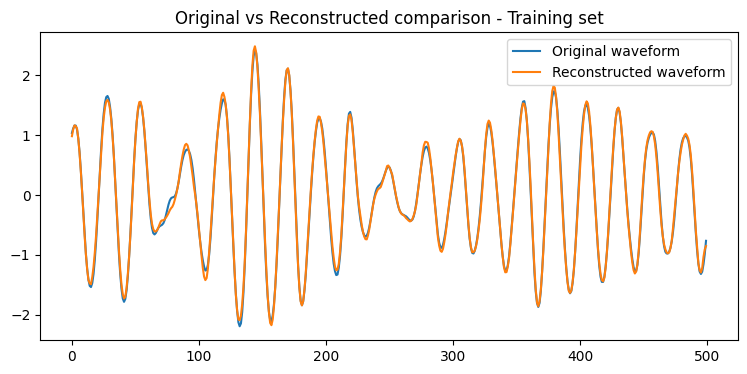

In [ ]:
# ------------------------------------
# MODEL TRAINING for the FordA dataset
# ------------------------------------

FordA_model = ec.AutoEncoder()

# This comand put the model in training mode 
# that means that some mathematichal structures are behaving in a specific mode
FordA_model.train() 

trained_ae_FordA = ec.train_autoencoder(FordA_model, train_loader, epochs=500)

Recontruction - Test result: Average loss: 0.0055


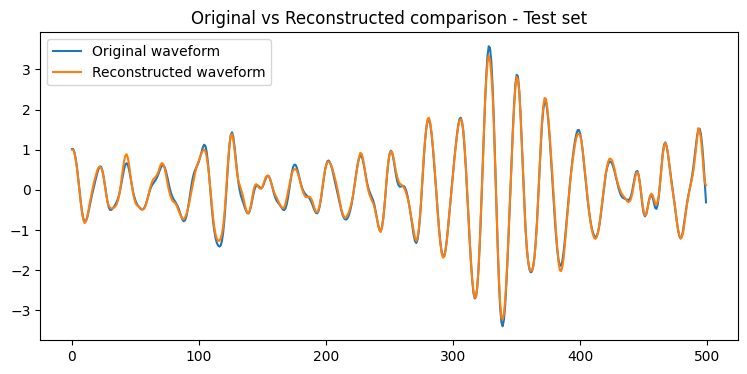

In [ ]:
# -----------------------
# TEST of the FordA_model
# -----------------------

tested_ae_FordA = ec.test_autoencoder(trained_ae_FordA, test_loader)


# 2. CLASSIFIER

In [ ]:
# -----------------------
# TRAIN of the CLASSIFIER
# -----------------------

FordA_classifier = ec.Classifier()

classifier_FordA = ec.train_classifier(trained_ae_FordA, FordA_classifier, train_loader, epochs=500)

Epoch [1/500] - Loss: 0.6926 - Accuracy: 52.82%
Epoch [2/500] - Loss: 0.6871 - Accuracy: 53.62%
Epoch [3/500] - Loss: 0.6800 - Accuracy: 55.01%
Epoch [4/500] - Loss: 0.6737 - Accuracy: 57.51%
Epoch [5/500] - Loss: 0.6603 - Accuracy: 59.73%
Epoch [6/500] - Loss: 0.6346 - Accuracy: 63.79%
Epoch [7/500] - Loss: 0.6176 - Accuracy: 65.43%
Epoch [8/500] - Loss: 0.6174 - Accuracy: 64.23%
Epoch [9/500] - Loss: 0.5808 - Accuracy: 70.09%
Epoch [10/500] - Loss: 0.5621 - Accuracy: 70.95%
Epoch [11/500] - Loss: 0.5413 - Accuracy: 73.29%
Epoch [12/500] - Loss: 0.5255 - Accuracy: 74.62%
Epoch [13/500] - Loss: 0.5208 - Accuracy: 74.17%
Epoch [14/500] - Loss: 0.5085 - Accuracy: 75.42%
Epoch [15/500] - Loss: 0.4888 - Accuracy: 77.03%
Epoch [16/500] - Loss: 0.4812 - Accuracy: 76.42%
Epoch [17/500] - Loss: 0.4791 - Accuracy: 77.01%
Epoch [18/500] - Loss: 0.4675 - Accuracy: 77.92%
Epoch [19/500] - Loss: 0.4627 - Accuracy: 78.89%
Epoch [20/500] - Loss: 0.4426 - Accuracy: 79.62%
Epoch [21/500] - Loss: 0.4395

In [ ]:
# ----------------------
# TEST of the CLASSIFIER
# ----------------------

tested_classifier_FordA = ec.test_classifier(classifier_FordA, test_loader)
